# Project Work NLP: Analisi della Distorsione e Omogeneizzazione della Scrittura da parte degli LLM

Questo notebook esplora l'impatto dei Modelli Linguistici di Grandi Dimensioni (LLM) sulla scrittura umana, implementando un'analisi basata su due recenti studi:

1. L'analisi di *"How LLMs Distort Our Written Language"* (2026), che dimostra come l'uso dell'IA come co-pilota di scrittura tenda a cancellare l'identità dell'autore, generando una "voce algoritmica" omogeneizzata.
2. L'indagine di *"Scientific production in the era of large language models"* (Science, 2025), che evidenzia come l'IA alteri la complessità linguistica spingendo verso un linguaggio iper-formale e artificiale.

Al fine di approfondire sperimentalmente i risultati emersi, questo project work è organizzato in tre esperimenti, ognuno dedicato all'analisi di uno specifico effetto degli LLM sulla produzione testuale.

* **Esperimento 1 - Entropia, Perplessità e Burstiness:** Analisi di come varia la prevedibilità statistica e la complessità strutturale del testo passando dalla bozza umana iniziale, alla revisione manuale, fino alla revisione artificiale (utilizzando il dataset *ArgRewrite*).
* **Esperimento 2 - Classificazione con BERT:** Addestramento di un modello Transformer (*DistilBERT*) per verificare se le firme stilistiche lasciate dall'IA sono sufficientemente marcate da essere distinte in un task di classificazione multiclasse.
* **Esperimento 3 - Collasso della Diversità Lessicale:** Replicazione della metodologia applicata alle recensioni *ICLR 2026* per misurare la perdita di varietà del vocabolario (tramite Type-Token Ratio) confrontando testi puramente umani e testi generati da IA su un dataset indipendente.

---

### Configurazione dell'Ambiente e Importazione delle Librerie
In questa cella viene configurato l'ambiente importando i pacchetti necessari per la manipolazione dei dati (`pandas`, `numpy`), la visualizzazione grafica (`matplotlib`, `seaborn`) e il calcolo delle metriche linguistiche avanzate (`transformers`, `nltk`, `textstat`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import nltk
import textstat

# download dei tokenizzatori NLTK per dividere il testo in frasi e parole
nltk.download('punkt')
nltk.download('punkt_tab')

# setup grafico per le curve evolutive temporali
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Marco\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


### Caricamento dei Dati e Allineamento Temporale

Prima di estrarre le metriche linguistiche, strutturiamo il dataset in modo da allineare ogni singolo saggio lungo il suo ciclo vitale. 

Attraverso l'integrazione del corpus **ArgRewrite V.2** (per i testi umani) e delle riscritture contenute in `dataframe_essays_llm_model.csv` (per i modelli generativi), costruiamo un unico DataFrame unificato (`df_timeline`). 

Ogni riga del DataFrame rappresenta un saggio tracciato in tre momenti storici:
1. **$t_0$ (Bozza Iniziale)**: Il testo grezzo scritto dallo studente prima di ricevere feedback (`Draft1`).
2. **$t_1$ (Revisione Umana)**: L'evoluzione naturale del saggio rivista dallo studente a seguito dei commenti (`Draft2`).
3. **$t_1^*$ (Riscrittura IA)**: La revisione parallela generata dall'LLM di riferimento a partire dalla bozza $t_0$ e dal feedback.

Questo allineamento ci permetterà di confrontare direttamente la traiettoria evolutiva dell'apprendimento umano contro la traiettoria di riscrittura sintetica dell'IA.

In [2]:
PATH_ANALYSIS = "./data/argrewrite_analysis"
csv_real_path = os.path.join(PATH_ANALYSIS, "dataframe_essays_llm_model.csv")

if os.path.exists(csv_real_path):
    df_raw = pd.read_csv(csv_real_path)
    
    modelli_disponibili = df_raw["llm_model"].unique()

    print(f"[DATA] Modelli LLM presenti nel dataset: {list(modelli_disponibili)}")

    # selezioniamo il primo modello LLM disponibile
    modello_target = modelli_disponibili[0]
    
    df_filtered = df_raw[df_raw["llm_model"] == modello_target].copy()
    
    # costruzione del DataFrame timeline
    df_timeline = pd.DataFrame({
        "essay_id": df_filtered["essay_id"],
        "t0_bozza": df_filtered["draft1"],
        "t1_umano": df_filtered["draft2"],
        "t1_ia": df_filtered["ai_text"],
        "llm_model": df_filtered["llm_model"]
    }).dropna().reset_index(drop=True)
    
    print(f"[DATA] Caricamento completato con il modello: '{modello_target}'")
    print(f"[DATA] Totale saggi caricati lungo la timeline: {len(df_timeline)}")
else:
    raise FileNotFoundError(f"Impossibile trovare il file: {csv_real_path}")

[DATA] Modelli LLM presenti nel dataset: ['CLAUDE-HAIKU-4-5-20251001', 'GPT-5-MINI', 'GEMINI-2.5-FLASH']
[DATA] Caricamento completato con il modello: 'CLAUDE-HAIKU-4-5-20251001'
[DATA] Totale saggi caricati lungo la timeline: 860


---

## Esperimento 1 - Evoluzione Temporale delle Metriche Linguistiche

### Obiettivo
In questo primo esperimento vogliamo misurare quantitativamente come si trasforma l'impronta stilistica di un testo durante il suo processo di revisione. La letteratura scientifica suggerisce che l'intervento di un LLM tenda ad "appiattire" il testo, rendendolo statisticamente più prevedibile e strutturalmente monotono, aumentandone però al contempo la complessità del vocabolario.

Per dimostrarlo, analizzeremo l'evoluzione delle grandezze testuali confrontando tre fasi temporali distinte:
1. **$T_0$ (Bozza Iniziale):** Il saggio originale scritto dallo studente.
2. **$T_1$ Umano (Revisione Manuale):** Il saggio corretto dallo studente seguendo il feedback del docente.
3. **$T_1$ IA (Revisione LLM):** Il saggio originale fatto correggere a un modello IA utilizzando lo stesso feedback.

### Metriche Calcolate
Per tracciare questa evoluzione estrarremo quattro grandezze fondamentali:

* **Entropia (Cross-Entropy Loss):** Misura il grado di incertezza del modello nel prevedere la parola successiva. Testi molto "standardizzati" dall'IA presentano un'entropia minore.
* **Perplessità (Perplexity):** Direttamente derivata dall'entropia, indica quanto il testo sia "sorprendente" per un modello linguistico. Viene calcolata esponenzialmente:
  $$Perplexity = \exp(Entropy)$$
* **Burstiness (Esplosività Strutturale):** Valuta la varianza nella lunghezza delle frasi. Gli esseri umani alternano frasi brevi e lunghe (alta burstiness), mentre l'IA tende a produrre frasi di lunghezza uniforme. La calcoleremo tramite la deviazione standard del numero di parole per frase.
* **Leggibilità (Flesch Reading Ease):** Un indice per quantificare la difficoltà di lettura. L'obiettivo è verificare se la revisione dell'IA introduca una complessità sintattica artificiale rispetto alla revisione umana.

### Estrattore Metriche Linguistiche

In [3]:
# pulizia preventiva della VRAM
torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Dispositivo attivo: {device}")

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)
model.eval()

def calcola_entropia_perplessita(testo):
    """Calcola Loss e Perplexity estraendo la loss scalare senza caricare i Logits pesanti in VRAM."""
    if not isinstance(testo, str) or not testo.strip():
        return np.nan, np.nan
    
    inputs = tokenizer(testo, return_tensors="pt", truncation=True, max_length=512).to(device)
    
    if inputs.input_ids.shape[1] < 2:
        return np.nan, np.nan
        
    with torch.no_grad():
        # HuggingFace calcola la loss internamente in modo ultra-ottimizzato
        outputs = model(inputs.input_ids, labels=inputs.input_ids)
        loss = outputs.loss.item()
        perplexity = float(np.exp(loss))
        
    return loss, perplexity

# estrazione metriche
stadi = [("t0", "t0_bozza"), ("t1_h", "t1_umano"), ("t1_ai", "t1_ia")]

for prefisso, col_testo in stadi:
    print(f" -> Calcolo in corso per lo stadio '{prefisso}'...")
    
    entropie, perplessita, burstiness, leggibilita = [], [], [], []
    
    for testo in df_timeline[col_testo]:
        # 1. Calcolo GPT-2 su GPU
        e, p = calcola_entropia_perplessita(testo)
        
        # 2. Calcolo NLTK e Textstat su CPU
        if isinstance(testo, str) and testo.strip():
            frasi = nltk.sent_tokenize(testo)
            b = float(np.std([len(nltk.word_tokenize(f)) for f in frasi])) if len(frasi) > 1 else 0.0
            l = textstat.flesch_reading_ease(testo)
        else:
            b, l = 0.0, np.nan
            
        entropie.append(e)
        perplessita.append(p)
        burstiness.append(b)
        leggibilita.append(l)
        
    df_timeline[f"{prefisso}_entropy"] = entropie
    df_timeline[f"{prefisso}_perplexity"] = perplessita
    df_timeline[f"{prefisso}_burstiness"] = burstiness
    df_timeline[f"{prefisso}_readability"] = leggibilita

# pulizia finale VRAM
torch.cuda.empty_cache()

print("\n[SUCCESS] Calcolo completato con successo!")
print(df_timeline[["essay_id", "t0_perplexity", "t1_h_perplexity", "t1_ai_perplexity"]].head())

[INFO] Dispositivo attivo: cuda


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

 -> Calcolo in corso per lo stadio 't0'...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


 -> Calcolo in corso per lo stadio 't1_h'...
 -> Calcolo in corso per lo stadio 't1_ai'...

[SUCCESS] Calcolo completato con successo!
   essay_id  t0_perplexity  t1_h_perplexity  t1_ai_perplexity
0         1      21.090680        22.212243         14.772194
1         2      22.977983        20.354880         19.025180
2         3      28.630659        29.665382         24.515809
3         4      23.649038        19.020603         16.443756
4         5      21.972151        22.068511         19.177747


### Visualizzazione Grafica comparativa

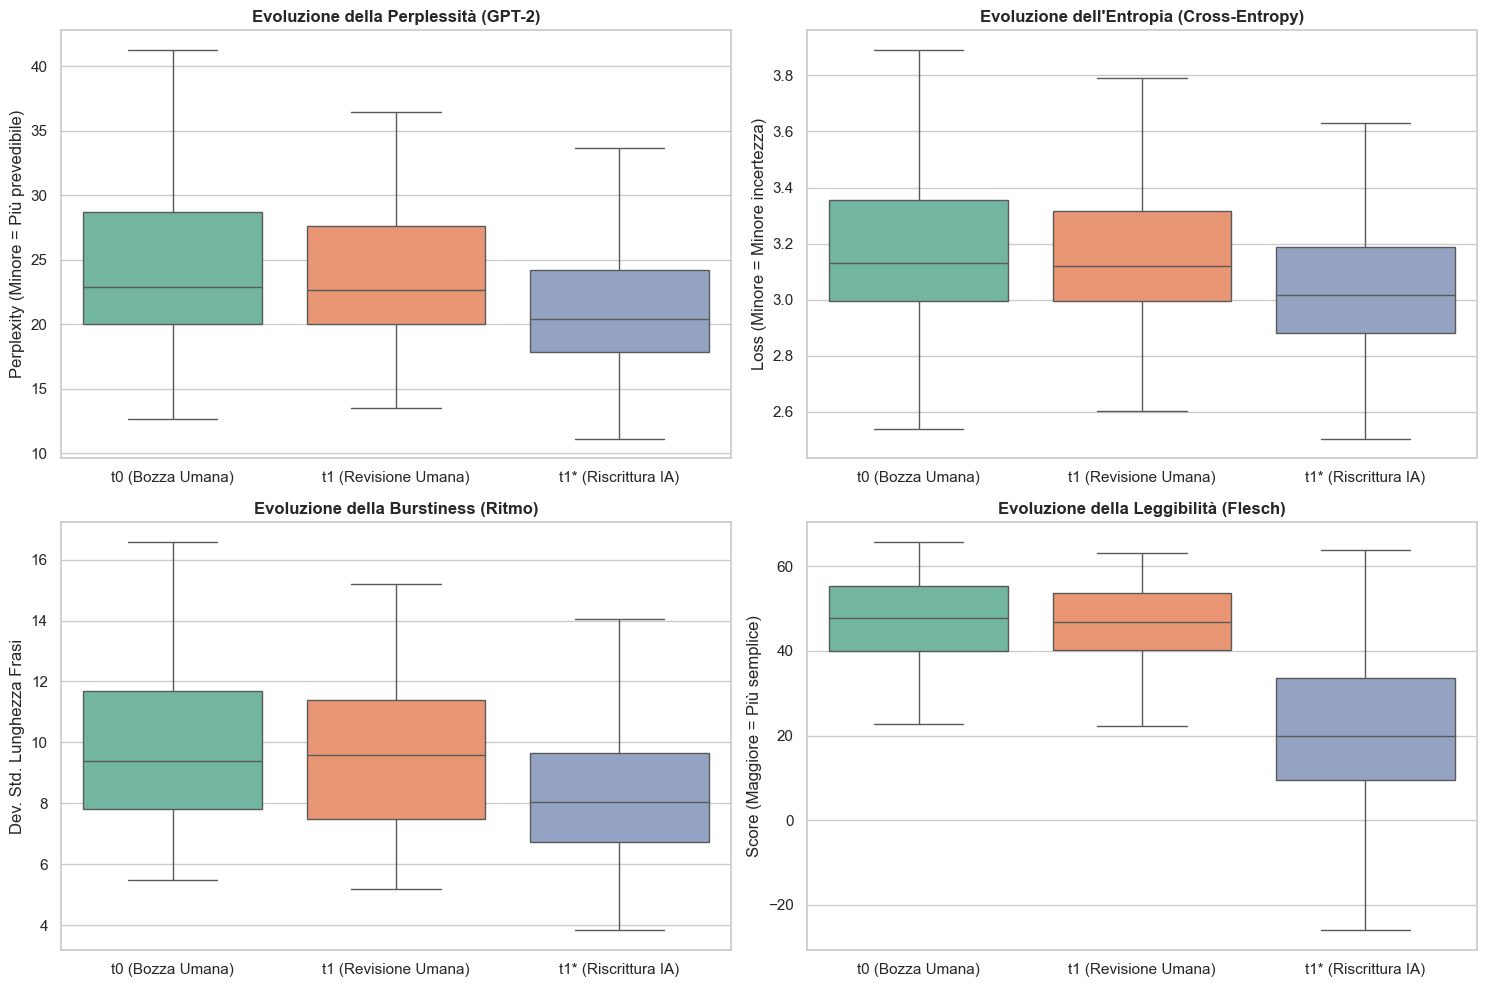

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metriche_config = [
    ("perplexity", "Evoluzione della Perplessità (GPT-2)", "Perplexity (Minore = Più prevedibile)", axes[0, 0]),
    ("entropy", "Evoluzione dell'Entropia (Cross-Entropy)", "Loss (Minore = Minore incertezza)", axes[0, 1]),
    ("burstiness", "Evoluzione della Burstiness (Ritmo)", "Dev. Std. Lunghezza Frasi", axes[1, 0]),
    ("readability", "Evoluzione della Leggibilità (Flesch)", "Score (Maggiore = Più semplice)", axes[1, 1])
]

for col, titolo, ylabel, ax in metriche_config:
    df_melt = pd.melt(
        df_timeline, 
        value_vars=[f"t0_{col}", f"t1_h_{col}", f"t1_ai_{col}"],
        var_name="Stadio", value_name="Valore"
    )
    df_melt["Stadio"] = df_melt["Stadio"].map({
        f"t0_{col}": "t0 (Bozza Umana)",
        f"t1_h_{col}": "t1 (Revisione Umana)",
        f"t1_ai_{col}": "t1* (Riscrittura IA)"
    })
    
    sns.boxplot(
        data=df_melt, x="Stadio", y="Valore", ax=ax, 
        hue="Stadio", palette="Set2", legend=False, showfliers=False
    )
    ax.set_title(titolo, fontsize=12, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


**Risultati del Grafico**

I quattro boxplot evidenziano una netta divergenza tra la revisione umana ($t_1$) e la riscrittura generata dall'IA ($t1^*$): mentre la correzione umana conserva la struttura e le metriche della bozza originale ($t_0$), l'intervento del modello altera significativamente l'impronta stilometrica del testo.

* **Perplessità ed Entropia:** La riscrittura $t1^*$ mostra una contrazione verso il basso della mediana e dell'intervallo interquartile. La diminuzione della perplessità e della loss indica che il testo dell'IA diventa statisticamente più prevedibile e uniforme rispetto alle bozze umane.
* **Burstiness (Ritmo):** La deviazione standard della lunghezza delle frasi diminuisce sensibilmente in $t1^*$, evidenziando una struttura sintattica più omogenea e priva della naturale variabilità ritmica che caratterizza sia $t_0$ sia $t_1$.
* **Leggibilità (Flesch):** Si osserva il calo più drastico: il punteggio medio crolla da circa 48 ($t_0$ e $t_1$) a circa 20 ($t1^*$). L'IA sposta forzatamente il testo verso un registro nettamente più complesso e iper-formale.

I dati confermano che la riscrittura sintetica non si limita a rifinire il testo, ma ne appiattisce la variabilità ritmico-statistica e ne appesantisce la struttura linguistica.

### Tabella Riassuntiva delle Medie e Deviazioni Standard

In [7]:
metriche_summary = {
    "Stadio": ["t0 (Bozza Umana)", "t1 (Revisione Umana)", "t1* (Riscrittura IA)"],
    "Entropy (Media ± Std)": [
        f"{df_timeline['t0_entropy'].mean():.2f} ± {df_timeline['t0_entropy'].std():.2f}",
        f"{df_timeline['t1_h_entropy'].mean():.2f} ± {df_timeline['t1_h_entropy'].std():.2f}",
        f"{df_timeline['t1_ai_entropy'].mean():.2f} ± {df_timeline['t1_ai_entropy'].std():.2f}"
    ],
    "Perplexity (Media ± Std)": [
        f"{df_timeline['t0_perplexity'].mean():.2f} ± {df_timeline['t0_perplexity'].std():.2f}",
        f"{df_timeline['t1_h_perplexity'].mean():.2f} ± {df_timeline['t1_h_perplexity'].std():.2f}",
        f"{df_timeline['t1_ai_perplexity'].mean():.2f} ± {df_timeline['t1_ai_perplexity'].std():.2f}"
    ],
    "Burstiness (Media ± Std)": [
        f"{df_timeline['t0_burstiness'].mean():.2f} ± {df_timeline['t0_burstiness'].std():.2f}",
        f"{df_timeline['t1_h_burstiness'].mean():.2f} ± {df_timeline['t1_h_burstiness'].std():.2f}",
        f"{df_timeline['t1_ai_burstiness'].mean():.2f} ± {df_timeline['t1_ai_burstiness'].std():.2f}"
    ],
    "Leggibilità Flesch (Media ± Std)": [
        f"{df_timeline['t0_readability'].mean():.2f} ± {df_timeline['t0_readability'].std():.2f}",
        f"{df_timeline['t1_h_readability'].mean():.2f} ± {df_timeline['t1_h_readability'].std():.2f}",
        f"{df_timeline['t1_ai_readability'].mean():.2f} ± {df_timeline['t1_ai_readability'].std():.2f}"
    ]
}

df_summary = pd.DataFrame(metriche_summary)
df_summary

,Stadio,Entropy (Media ± Std),Perplexity (Media ± Std),Burstiness (Media ± Std),Leggibilità Flesch (Media ± Std)
0,t0 (Bozza Umana),3.18 ± 0.29,25.18 ± 8.08,10.28 ± 3.33,47.09 ± 9.70
1,t1 (Revisione Umana),3.15 ± 0.28,24.21 ± 7.56,10.01 ± 3.40,46.14 ± 9.37
2,t1* (Riscrittura IA),3.03 ± 0.22,21.25 ± 4.83,8.49 ± 2.59,21.41 ± 16.29


**Analisi della Tabella Riassuntiva**

I valori quantitativi sintetizzati nella tabella confermano con precisione numerica il comportamento osservato nei grafici:

* **Stabilità della Revisione Umana ($t_0 \rightarrow t_1$):** Il passaggio dalla bozza alla correzione umana mantiene la sostanziale stabilità di tutti gli indici (Perplessità da 25.18 a 24.21, Entropia da 3.18 a 3.15, Burstiness da 10.28 a 10.01, Flesch da 47.09 a 46.14), dimostrando che l'editing dello studente rispetta l'impronta distributiva e lo stile dell'autore.
* **Contrazione delle Metriche con l'IA ($t1^*$):** La riscrittura sintetica registra una riduzione sistematica in tutte le metriche e nelle relative deviazioni standard: l'Entropia scende a $3.03 \pm 0.22$, la Perplessità a $21.25 \pm 4.83$ e la Burstiness a $8.49 \pm 2.59$. Ciò riflette una forte omogeneizzazione statistica e una perdita di varietà ritmico-lessicale.
* **Crollo dell'Indice Flesch:** La leggibilità registra il divario più marcato, crollando a $21.41 \pm 16.29$ rispetto al $\sim 46-47$ dei testi umani, confermando la tendenza dell'LLM a strutturare frasi significativamente più complesse e formalmente sovraccariche.

### Conclusioni Esperimento 1

I risultati empirici ottenuti dall'analisi degli 860 saggi mostrano una marcata divergenza tra le dinamiche di revisione umana e l'intervento dei modelli linguistici, evidenziando come l'IA non si limiti a un'opera di correzione formale, ma riplasmi in profondità l'architettura del testo.

* **Conservazione dell'Impronta Autoriale ($t_0 \rightarrow t_1$):** La revisione svolta dagli studenti si configura come un processo incrementale e organico. Le metriche di perplessità, entropia e burstiness rimangono pressoché inalterate, dimostrando che l'editing umano preserva la variabilità statistica, la naturale alternanza ritmica delle frasi e il livello di accessibilità cognitiva del testo originale.
* **Standardizzazione e Omogeneizzazione ($t_0 \rightarrow t_1^*$):** La riscrittura generativa opera un appiattimento sistematico dell'impronta stilistica. La contrazione simultanea di perplessità ed entropia segnala la convergenza verso sequenze lessicali statisticamente più prevedibili, mentre il crollo della burstiness elimina le fluttuazioni sintattiche tipiche della scrittura umana, sostituendole con frasi dalla struttura regolare e uniforme.
* **Iper-Formalizzazione Artificiale:** Il marcato abbassamento dell'indice di Flesch rivela una spinta forzata verso un registro linguistico complesso e sovraccarico. L'LLM tende ad appesantire la sintassi e a introdurre vocaboli a bassa frequenza, alterando la fruibilità del saggio e imponendo uno stile artificiosamente accademico.

In sintesi, mentre l'intervento umano affina la forma senza snaturare la voce dell'autore, la riscrittura sintetica sovrascrive la firma stilometrica individuale, lasciando un'impronta algoritmica caratterizzata da alta prevedibilità e rigidità strutturale. Questa distinta traccia statistica fornisce la giustificazione empirica per l'Esperimento 2, dimostrando la fattibilità di un classificatore automatico in grado di discriminare con precisione la provenienza e lo stadio evolutivo del testo.

   